Machine Learning: Algoritmo KNN  

## **Intro Teoría KNN**

* K-Nearest Neighbors (KNN) es un algoritmo de Machine Learning supervisado utilizado para problemas de clasificación y regresión.

El algoritmo realiza predicciones basándose en la similitud entre observaciones. Para ello calcula la distancia entre un nuevo punto de datos y los datos existentes en el conjunto de entrenamiento.

La idea principal es que observaciones similares tienden a pertenecer a la misma clase o tener valores similares.

Por ejemplo, si queremos clasificar un nuevo vino como bueno o malo, el algoritmo observará los K vinos más parecidos y asignará la clase más frecuente entre ellos.

* Qué significa K

El parámetro K representa el número de vecinos más cercanos que se utilizan para realizar la predicción.

K pequeño
El modelo es más sensible al ruido y a los outliers.

K grande
El modelo es más estable pero puede perder capacidad de capturar patrones locales.

Elegir el valor adecuado de K es fundamental para el rendimiento del modelo.


* Métricas de distancia (tu duda)

Las métricas de distancia permiten medir qué tan similares son dos observaciones.

Las más utilizadas en KNN son:

Distancia Euclídea (p = 2)
Es la distancia geométrica tradicional entre dos puntos.

Distancia Manhattan (p = 1)
Suma de las diferencias absolutas entre variables.

Distancia Minkowski
Generalización de las anteriores.

En sklearn, el parámetro p controla esto: p = 1 → Manhattan, p = 2 → Euclídea

* Clasificación vs Regresión

Clasificación

La variable objetivo pertenece a categorías o clases.

Ejemplos:

Diagnosticar diabetes / no diabetes

Clasificar vinos buenos / malos

Regresión

La variable objetivo es numérica continua.

Ejemplo:

Predecir precio de una casa

Predecir gasto de un cliente

* Cómo trabaja el algoritmo KNN

El funcionamiento del algoritmo KNN se puede resumir en cuatro pasos:

1. Selección del valor de K

Se define cuántos vecinos cercanos se utilizarán para realizar la predicción.

2. Cálculo de distancias

Se calcula la distancia entre el nuevo punto y todos los puntos del dataset.

3. Selección de los K vecinos más cercanos

Se seleccionan las K observaciones con menor distancia.

4. Predicción

En clasificación → se asigna la clase más frecuente entre los vecinos.

En regresión → se calcula la media o mediana de los vecinos.



# **EDA**


> * Datos sobre: busca analizar e investigar los conjuntos de datos de los que disponen y resumir sus principales características, visualización de datos para ver su comportamiento y distribución de los mismos.
> * Objetivo: Determinar las mejores variables enfocando el análisis a buscar los vinos de calidad "buena" o "mala".
> * Enfoque: Método de clasificación binaria y multiclase

## Paso 0: **Imports & Read data**


In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import plotly.express as px # Graficos tridimensionales DUDA pip install
import seaborn as sns


### **Definición de la información del conjunto de datos**

* **Creamos el DataFrame:**

In [60]:
df = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv", sep=";")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


> **Observaciones:**    
> * .info():
    - La 1ª columna "#" indica el índex de las variables y la 2ª su nombre/indicador.
    - La 3ª columna cuenta los valores no nulos, dónde sí tenemos data en cada fila y el restante en comparación al total de filas serán las filas que contienen valores nulos. ¿Hay valores NaN? ¿Dónde?
    - La 4ª columna nos dice el tipo de dato que contienen las variables, numéricos o objeto.
    - Por último tenemos un recuento de los tipo de variable y cuánto ocupa en la memoria el total del df.   
> * Columnas: El dataset contiene información química sobre vinos tintos. Cada fila representa un vino analizado en laboratorio, mientras que cada columna representa una característica química del vino.  
> * Target: Nuestro objetivo será clasificar los vinos en categorías.

In [62]:
df.describe().T.round(2).sort_values("mean", ascending=False)

,count,mean,std,min,25%,50%,75%,max
total sulfur dioxide,1599.0,46.47,32.90,6.00,22.00,38.00,62.00,289.00
free sulfur dioxide,1599.0,15.87,10.46,1.00,7.00,14.00,21.00,72.00
alcohol,1599.0,10.42,1.07,8.40,9.50,10.20,11.10,14.90
fixed acidity,1599.0,8.32,1.74,4.60,7.10,7.90,9.20,15.90
quality,1599.0,5.64,0.81,3.00,5.00,6.00,6.00,8.00
pH,1599.0,3.31,0.15,2.74,3.21,3.31,3.40,4.01
residual sugar,1599.0,2.54,1.41,0.90,1.90,2.20,2.60,15.50
density,1599.0,1.00,0.00,0.99,1.00,1.00,1.00,1.00
sulphates,1599.0,0.66,0.17,0.33,0.55,0.62,0.73,2.00
volatile acidity,1599.0,0.53,0.18,0.12,0.39,0.52,0.64,1.58


### **Descripción de la data inicial** 


#### **Variable target:**

In [63]:
df["quality"].unique()

array([5, 6, 7, 4, 8, 3])

> **Observaciones:** Vemos que en la columna Quality tenemos un rango de calidades que va del 3 al 8 haciendo referencia de menor a mayor calidad de cada vino.

> **Filtrado de la columna target por rangos:** Nueva columna 'range_quality' que contiene valor tipo object-string.
>      
> * df_binclass: buena  y mala
> * df_multiclass: low=0, medium=1, high=2

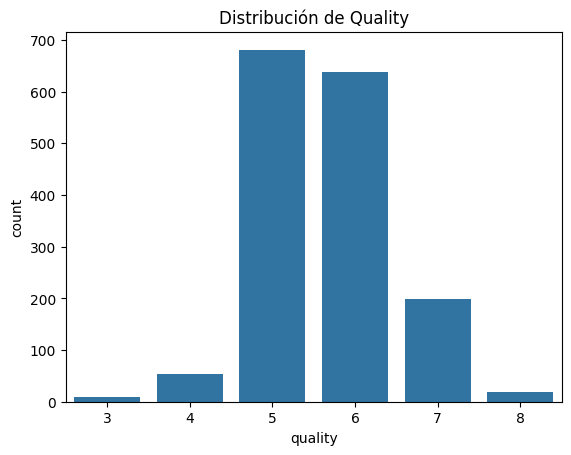

In [64]:
sns.countplot(x="quality", data=df)
plt.title("Distribución de Quality")
plt.show()

## Paso 1: **Limpieza de datos**






### **Valores NaNs**


In [65]:
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

**Observaciones:** No existen nulos en el df

### **Valores duplicados**

In [66]:
df.duplicated().sum()

np.int64(240)

In [67]:
df.sample(5, random_state=0)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1109,10.8,0.470,0.43,2.10,0.171,27.0,66.0,0.99820,3.17,0.76,10.8,6
1032,8.1,0.820,0.00,4.10,0.095,5.0,14.0,0.99854,3.36,0.53,9.6,5
1002,9.1,0.290,0.33,2.05,0.063,13.0,27.0,0.99516,3.26,0.84,11.7,7
487,10.2,0.645,0.36,1.80,0.053,5.0,14.0,0.99820,3.17,0.42,10.0,6
979,12.2,0.450,0.49,1.40,0.075,3.0,6.0,0.99690,3.13,0.63,10.4,5


**Observaciones:** Que hago con los duplicados? son relevantes? porque? hay diferencias en duplicados de los df multiclass y binario ? DUDA

### **Valores a 0**

In [68]:
(df == 0).sum()

fixed acidity             0
volatile acidity          0
citric acid             132
residual sugar            0
chlorides                 0
free sulfur dioxide       0
total sulfur dioxide      0
density                   0
pH                        0
sulphates                 0
alcohol                   0
quality                   0
dtype: int64

## Paso 2: **Análisis de Variables**



### **Defino los distintos datasets**

* **Defino el dataset binario:**

In [69]:
df_binclass = df.copy()

# Separación binaria:
df_binclass["range_quality"] = df["quality"].apply(lambda x: "buena" if x >= 6 else "mala") 
df_binclass.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,range_quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,mala
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,mala
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,mala
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,buena
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,mala


* **Defino el dataset multiclase:**

In [70]:
df_multiclass = df.copy()
# Separación multiclase:
def quality_to_label(q):
    if q <= 4:
        return 0  # low
    elif q <= 6:
        return 1  # medium
    else:
        return 2  # high

df_multiclass['target'] = df_multiclass['quality'].apply(quality_to_label)
df_multiclass.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,target
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1


### **Análisis de Distribucines Binaria:**



In [71]:
df_binclass["range_quality"].value_counts()

range_quality
buena    855
mala     744
Name: count, dtype: int64

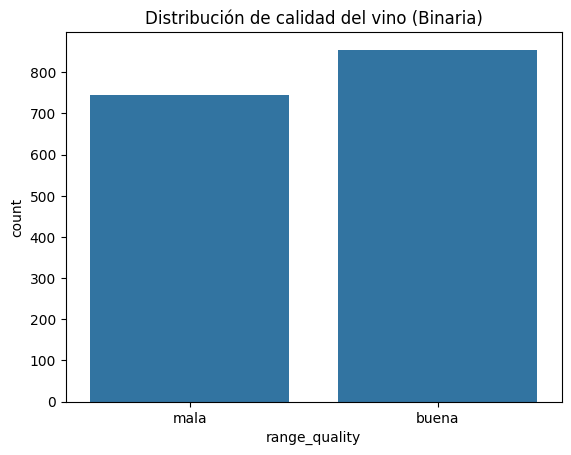

In [72]:
sns.countplot(data=df_binclass, x="range_quality")
plt.title("Distribución de calidad del vino (Binaria)")
plt.show()

### **Análisis de Distribucines Multiclase:**

In [73]:
df_multiclass["target"].value_counts()

target
1    1319
2     217
0      63
Name: count, dtype: int64

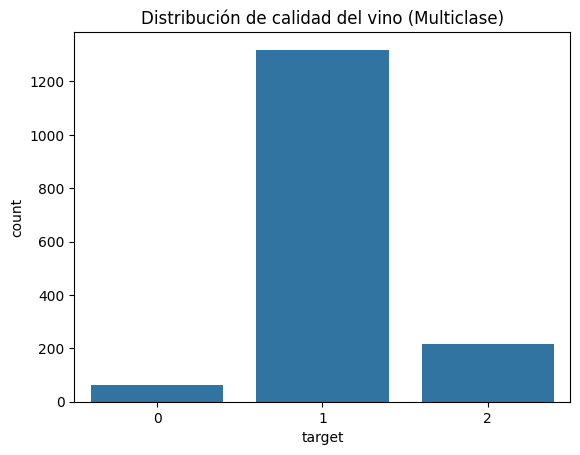

In [74]:
sns.countplot(data=df_multiclass, x="target")
plt.title("Distribución de calidad del vino (Multiclase)")
plt.show()

## Paso 3: **Preparación de datos para ML**

* **Binario:**

In [75]:
X_bin = df_binclass.drop(["quality", "range_quality"], axis=1)
y_bin = df_binclass["range_quality"]

* **Multiclase:**

In [80]:
X_multi = df_multiclass.drop(["quality","target"], axis=1)
y_multi = df_multiclass["target"]

# **ML**

## Paso 0: **Imports ML**

In [91]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Modelos
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Métricas
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Paso 1: **Lectura de los datos procesados**

In [ ]:
# df_binclass.to_csv("../data/processed/k-nearest-winequality-red.csv", index=False)
# df_binclass= pd.read_csv('../data/processed/k-nearest-winequality-red.csv')
# pd.DataFrame(df_binclass)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,range_quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,mala
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,mala
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,mala
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,buena
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,mala
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,mala
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,buena
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,buena
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,mala


## Paso 2: **Split data**

**Nota:** Importante: fit_transform solo en train, transform en test. Si haces fit en todo, hay data leakage (el modelo "ve" información del test durante el entrenamiento).

* **Binario:**

In [82]:
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_bin, y_bin, test_size=0.2, random_state=42)

* **Multiclase:**

In [81]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

**Escalado de valores:**

In [83]:
scaler = StandardScaler()

X_train_b = scaler.fit_transform(X_train_b)
X_test_b = scaler.transform(X_test_b)

X_train_m = scaler.fit_transform(X_train_m)
X_test_m = scaler.transform(X_test_m)


## Paso 3: **Modelado y entrenamiento** 


### **Modelo base**

* **Clasificación Binaria:**

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_b, y_train_b)

y_pred_knn = knn.predict(X_test_b)

print("Accuracy KNN:", accuracy_score(y_test_b, y_pred_knn))
print(classification_report(y_test_b, y_pred_knn))

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


**Matriz de confusión para Modelo base binario:**

In [ ]:
cm = confusion_matrix(y_test_b, y_pred_knn)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - KNN Binario")
plt.show()

* **Clasificación Multiclase:**

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_m, y_train_m)

y_pred_knn_m = knn.predict(X_test_m)

print("Accuracy KNN:", accuracy_score(y_test_m, y_pred_knn_m))
print(classification_report(y_test_m, y_pred_knn_m))

dummy¿? DUDA

In [ ]:
predictor_mode = DummyClassifier(strategy='most_frequent')
predictor_mode.fit(X_train, y_train);

predicciones_mode = predictor_mode.predict(X_test)

accuracy_mode = accuracy_score(y_test, predicciones_mode)
print("Accuracy base:", accuracy_mode)


## **Comparacion de modelos**

### **Modelos para la Clasificación Binaria**

In [92]:
models = {

    "KNN": KNeighborsClassifier(n_neighbors=5),

    "Logistic Regression": LogisticRegression(max_iter=200),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(random_state=42),

     "SVM": SVC()
}

In [93]:
results_bin = {}

for name, model in models.items():

    model.fit(X_train_b, y_train_b)

    pred = model.predict(X_test_b)

    acc = accuracy_score(y_test_b, pred)

    results_bin[name] = acc

results_bin

{'KNN': 0.70625,
 'Logistic Regression': 0.740625,
 'Decision Tree': 0.734375,
 'Random Forest': 0.78125,
 'SVM': 0.771875}

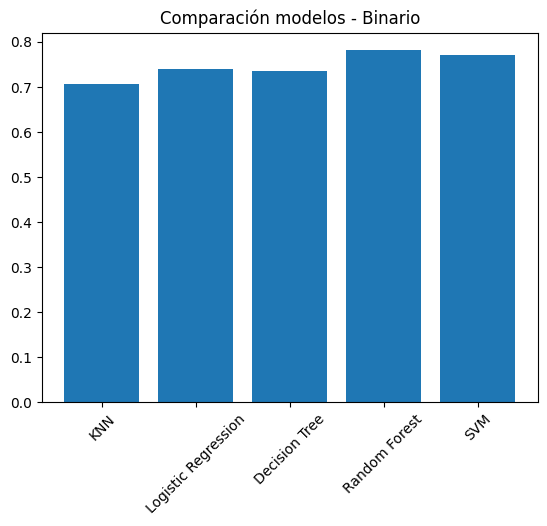

In [95]:
plt.bar(results_bin.keys(), results_bin.values())

plt.title("Comparación modelos - Binario")

plt.xticks(rotation=45)

plt.show()

## **Modelos para la Clasificación Multiclase**

In [94]:
results_multi = {}

for name, model in models.items():

    model.fit(X_train_m, y_train_m)

    pred = model.predict(X_test_m)

    acc = accuracy_score(y_test_m, pred)

    results_multi[name] = acc

results_multi

{'KNN': 0.84375,
 'Logistic Regression': 0.828125,
 'Decision Tree': 0.784375,
 'Random Forest': 0.86875,
 'SVM': 0.840625}

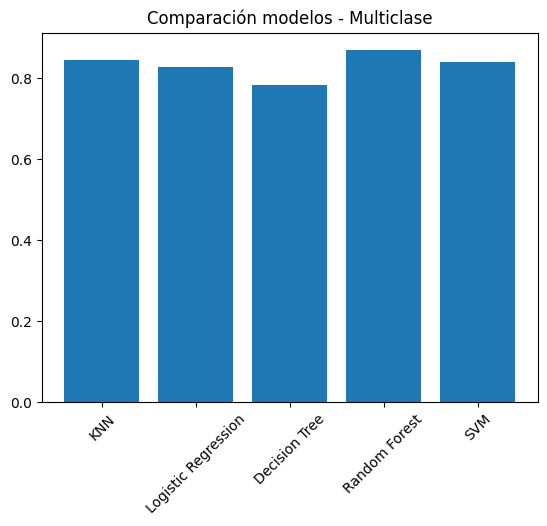

In [96]:
plt.bar(results_multi.keys(), results_multi.values())

plt.title("Comparación modelos - Multiclase")

plt.xticks(rotation=45)

plt.show()

## **Conclusiones finales**

Clasificación binaria

El objetivo fue clasificar los vinos como buena o mala calidad utilizando distintos modelos supervisados.
El modelo principal fue KNN, que clasifica observaciones según la distancia a sus vecinos más cercanos.

Clasificación multiclase

También se evaluó un enfoque multiclase:

low

medium

high

Este problema es más complejo porque el modelo debe diferenciar entre tres clases.

Comparación de modelos

Se compararon distintos modelos:

KNN

Logistic Regression

Decision Tree

Random Forest

SVM

Los modelos ensemble como Random Forest suelen ofrecer mejor rendimiento, mientras que KNN sigue siendo un modelo simple e interpretable.

### **Matriz de confusión**

In [ ]:
cm = confusion_matrix(y_test_m, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

### Conclusiones: 

* **Clasificación Binaria**

El modelo intenta predecir si la calidad del vino es buena o mala.
Se observó que modelos ensemble como Random Forest suelen obtener mejor rendimiento que modelos lineales.

* **Clasificación Multiclase**

Se clasificó el vino en tres niveles:

## Paso 4: **Overfitting**


### (1) **DataFrame comparativo entre las predicciones y la data de testeo**


* Usamos X_test para predecir
* Análisis Overfitting con x_train vs X_test


In [ ]:
y_pred_test = knn_model.predict(X_test)
y_pred_test


array(['mala', 'buena', 'mala', 'buena', 'buena', 'buena', 'buena',
       'buena', 'mala', 'mala', 'buena', 'mala', 'mala', 'buena', 'buena',
       'mala', 'mala', 'mala', 'mala', 'buena', 'buena', 'buena', 'buena',
       'buena', 'buena', 'mala', 'mala', 'buena', 'mala', 'buena',
       'buena', 'buena', 'buena', 'mala', 'mala', 'mala', 'buena',
       'buena', 'buena', 'mala', 'buena', 'mala', 'buena', 'mala',
       'buena', 'mala', 'buena', 'buena', 'buena', 'mala', 'mala',
       'buena', 'buena', 'mala', 'mala', 'mala', 'mala', 'buena', 'buena',
       'buena', 'mala', 'buena', 'buena', 'buena', 'mala', 'mala',
       'buena', 'buena', 'mala', 'mala', 'buena', 'mala', 'buena',
       'buena', 'buena', 'buena', 'buena', 'buena', 'buena', 'mala',
       'mala', 'mala', 'buena', 'mala', 'buena', 'buena', 'buena', 'mala',
       'buena', 'mala', 'buena', 'mala', 'mala', 'mala', 'mala', 'mala',
       'buena', 'mala', 'mala', 'buena', 'buena', 'buena', 'mala',
       'buena', 'mala

In [ ]:
# df de comparación resultados df test con la predición
pred_vs_real = pd.DataFrame()
pred_vs_real["y_test"] = y_test
pred_vs_real["predicciones"] = y_pred_test
pred_vs_real

,y_test,predicciones
193,mala,mala
1450,buena,buena
614,buena,mala
1422,buena,buena
1247,mala,buena
...,...,...
463,mala,mala
100,buena,mala
836,buena,mala
452,buena,buena


In [ ]:
y_pred_train = knn_model.predict(X_train)
y_pred_train

array(['mala', 'buena', 'buena', ..., 'mala', 'buena', 'mala'],
      shape=(1279,), dtype=object)

In [ ]:
# df de comparación resultados df entrenamiento con la predición
pred_vs_real = pd.DataFrame()
pred_vs_real["y_train"] = y_train
pred_vs_real["predicciones"] = y_pred_train
pred_vs_real

,y_train,predicciones
819,mala,mala
1122,buena,buena
539,mala,buena
1111,buena,buena
1239,mala,buena
...,...,...
146,mala,buena
184,buena,mala
1431,buena,mala
395,buena,buena


In [ ]:
# Comparación de eficiencia entre las predicciones del df test y el df de entrenamiento
accuracy = {'Accuracy Test': accuracy_score(y_test, y_pred_test),
            'Accuracy Train': accuracy_score(y_train, y_pred_train)}
accuracy

{'Accuracy Test': 0.675, 'Accuracy Train': 0.7568412822517592}

## Paso 5: **Hiperparametrización y métricas**


### (1) **Hiperparametrización**

In [ ]:
hiper_params = {'n_neighbors': [3, 5, 7, 9, 11, 15, 21], 
                'weights': ['uniform', 'distance'],
                'p': [1, 2]}

In [ ]:
# n_neighbors debe ser una LISTA para que GridSearch pruebe varios valores -> teoria
# PJ 'n_neighbors': [3, 5, 7, 9, 11, 15, 21],

### (2) **Métricas del modelo de Clasificación**


* **Accuracy** (exactitud)



* **Precision**



* **Recall** (sensibilidad)


* **F1 score**


## PASO 6: **Matriz de confusión** Para modelos de clasificacion

Matriz de confusión: Esta matriz muestra cuántos valores se clasificaron correctamente o incorrectamente. Los valores diagonales representan aciertos y los otros representan errores.

Las metricas que obtengamos de este resultado seran las que comuniquemos en nuestro reporte final para decir que tan bien funciona el modelo predictivo que hemos seleccionado


DUDA::: Utilizando la caja negra predictora seleccionada y creando reporte final con el conjunto de prueba (X_test,y_test)


In [ ]:
matrix = confusion_matrix(y_test, y_pred)
print("Accuracy por clase:", matrix.diagonal()/matrix.sum(axis=1))
confussion_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(confussion_matrix, annot=True, fmt='g')
plt.xlabel('Predicho')
plt.ylabel('Real');

NameError: name 'y_pred' is not defined

**OBSERVACIONES:**

> 


### (2.1) **Matriz de confusión para la predicción en base a la moda**

In [ ]:
matrix_moda = confusion_matrix(y_test, predicciones_mode)
print("Accuracy por clase:", matrix_moda.diagonal()/matrix_moda.sum(axis=1))
confussion_matrix_mode = confusion_matrix(y_test, y_pred)
sns.heatmap(confussion_matrix_mode, annot=True, fmt='g')
plt.xlabel('Predicho')
plt.ylabel('Real');